# Partie 1 - Données tabulaires

In [1]:
from data_analysis import *
import pandas as pd

## 1. Analyse du jeu de données

### Utilisez ce que nous avons vu pendant les TPs. En utilisant les librairies panda et seaborn, indiquez par exemple si le jeu de données contient des données manquantes, explorez les différentes colonnes (type, modalités, plages de valeurs, cardinal, distributions, etc). 

#### Analyse du jeu de données - pas de preprocessing

In [2]:
df = pd.read_csv("RH_dataset.csv", sep=';', encoding='utf-8')
analysis_RH_raw=Analyzer(df)

Dataset ready: 23857 rows and 14 columns.


In [3]:
analysis_RH_raw.df.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

In [4]:
analysis_RH_raw.get_inventory()

,Column,Type,Cardinality,Missing,Details
0,Famille d'emploi,str,8,0,"Unique values: ['Production', 'Commercial/Busi..."
1,Dernière promotion (mois),float64,7670,0,"Range: [0.0, 152.97000122070312]"
2,Dernière augmentation (mois),float64,2934,0,"Range: [0.0, 84.05000305175781]"
3,Début de contrat (années),float64,2433,0,"Range: [0.0, 33.119998931884766]"
4,Ancienneté groupe (années),float64,3660,0,"Range: [0.0, 45.619998931884766]"
5,Etablissement,int64,35,0,"Range: [0, 36]"
6,Âge (années),int64,74,0,"Range: [20, 100]"
7,Parent,int64,2,0,"Unique values: [1, 0]"
8,Niveau hiérarchique,int64,4,0,"Unique values: [1, 2, 3, 4]"
9,Salaire (Euros),int64,4901,0,"Range: [2134, 18137]"


On plote les distributions sur toutes les colonnes numériques.

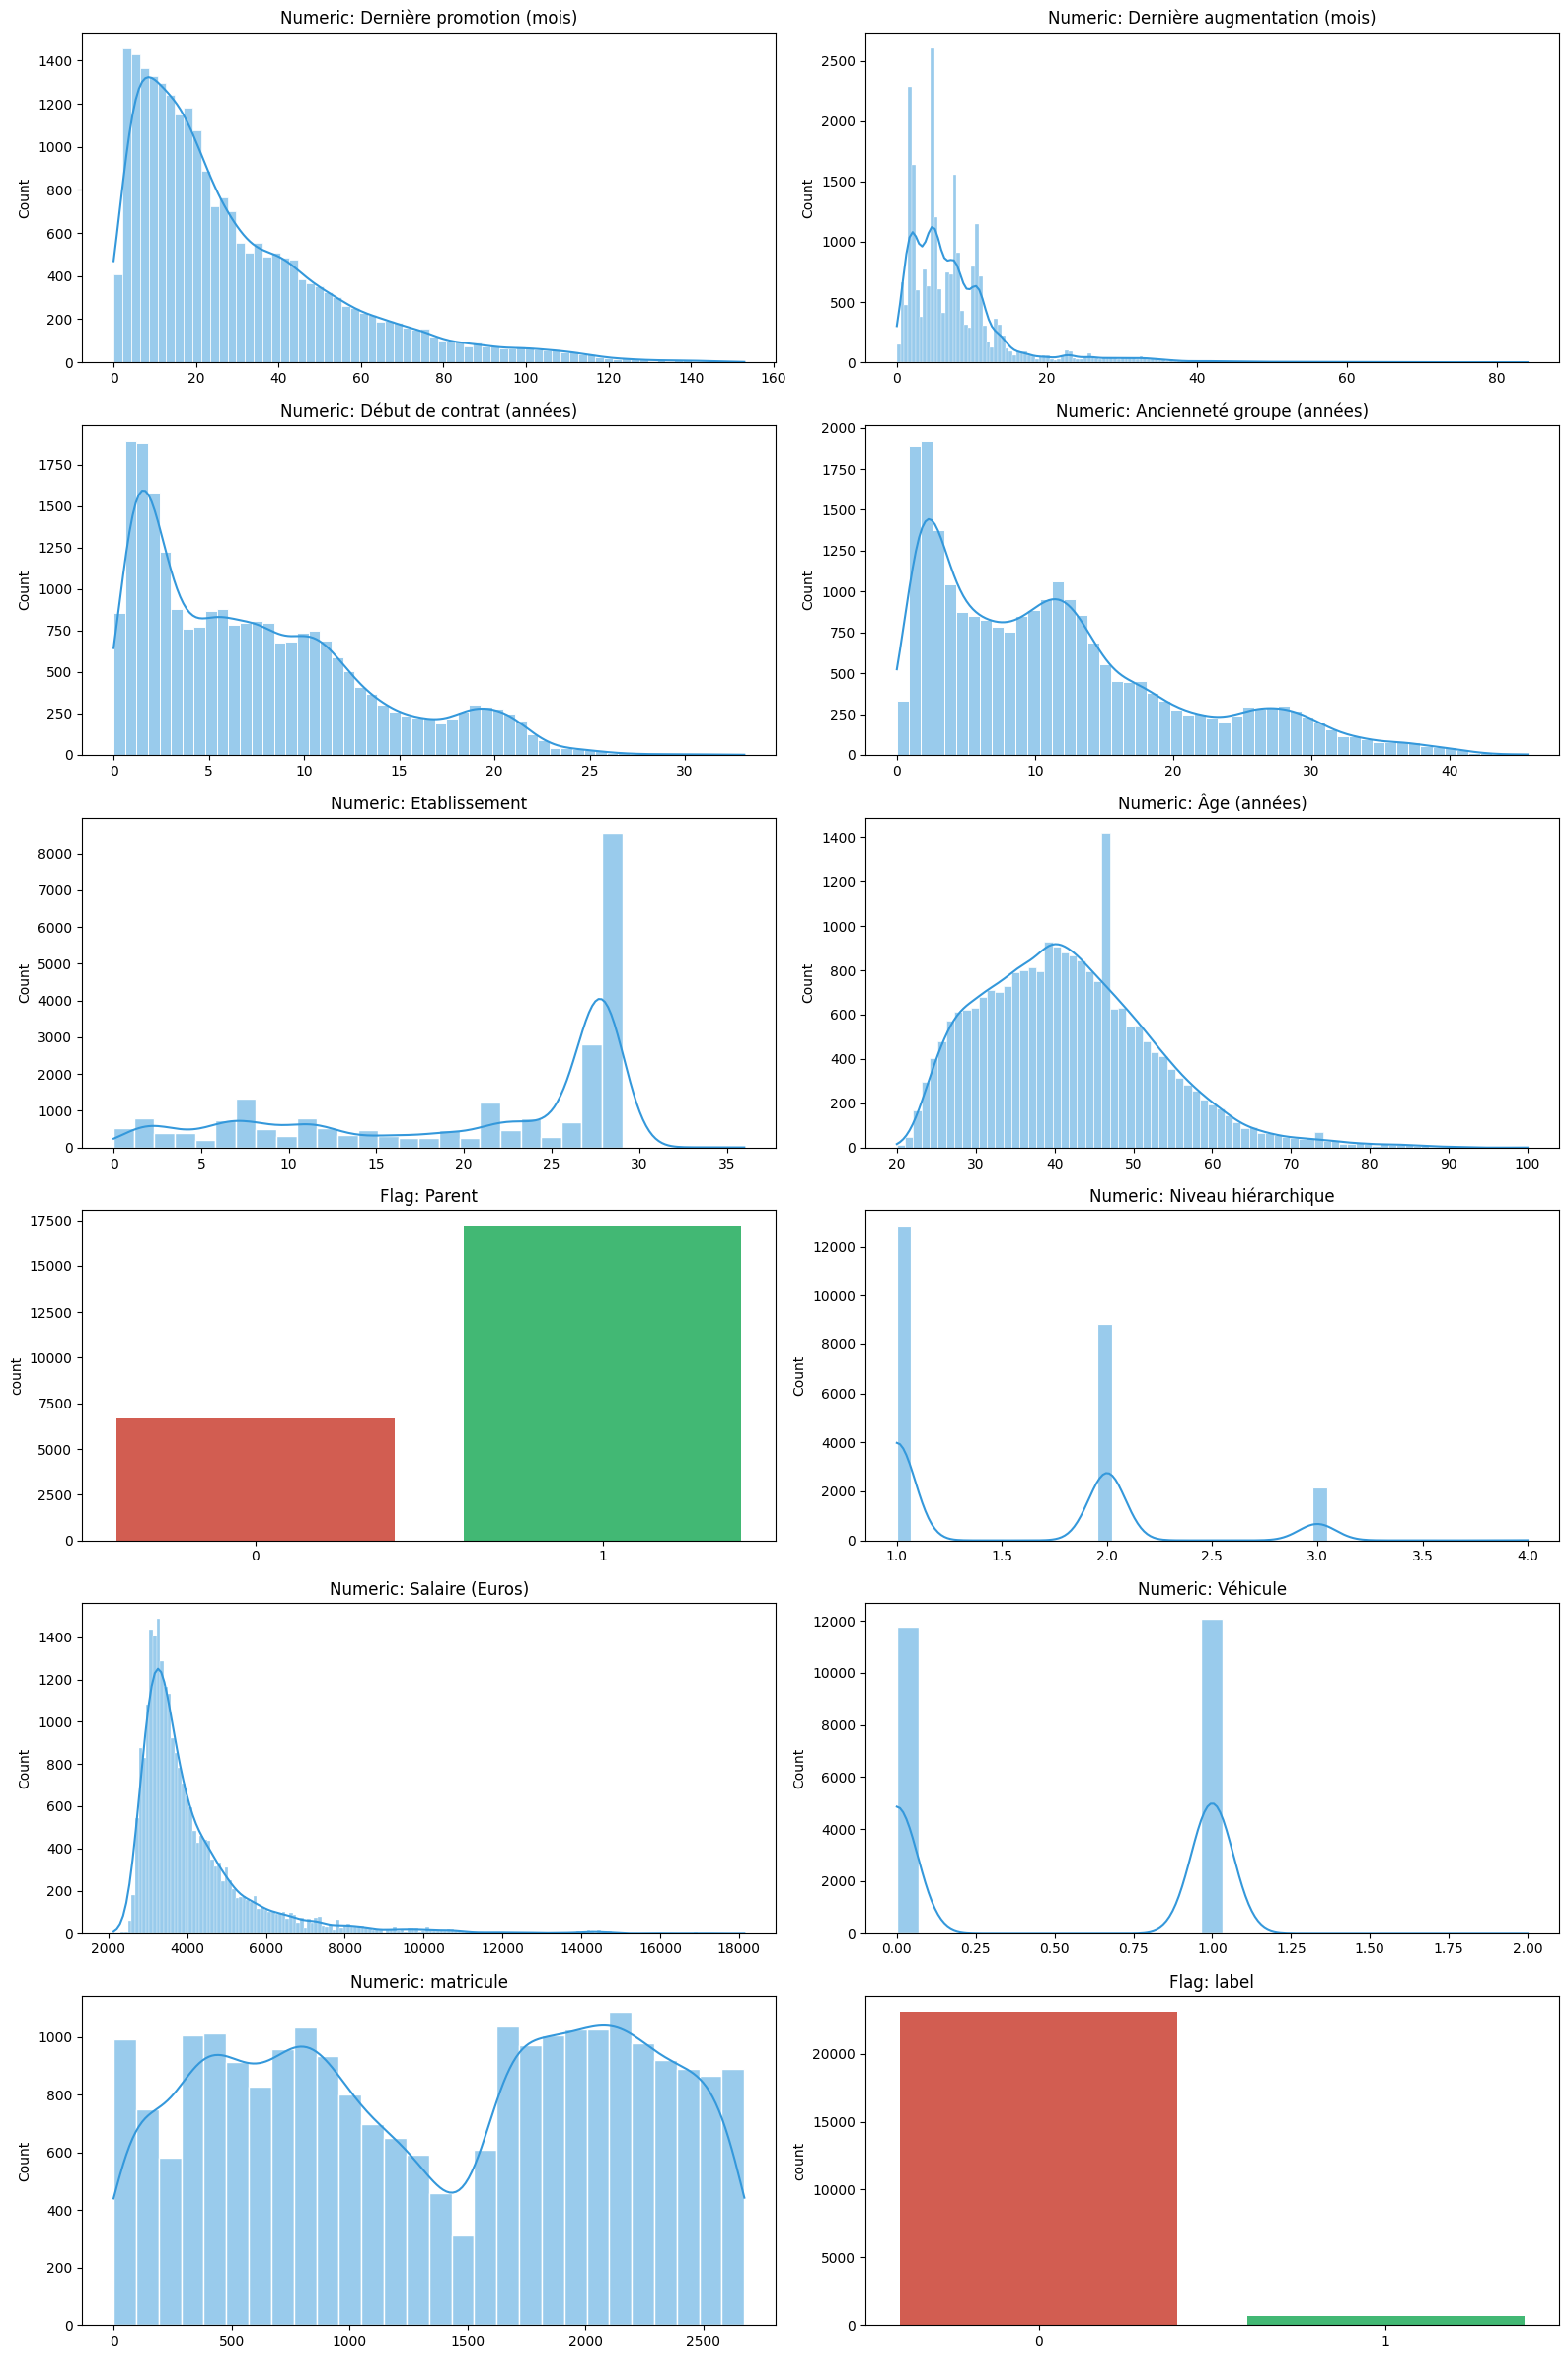

In [5]:
analysis_RH_raw.plot_distributions(['Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Véhicule',
       'matricule', 'label'])

#### Preprocessing sur les colonnes catégorielles

In [6]:
processed=DataPreprocessor(df).handle_encoding()

Encoding columns: ["Famille d'emploi", 'Statut marital']
Encoding complete. New shape: (23857, 29)


#### Analyse du jeu de données - après preprocessing des colonnes catégorielles

In [7]:
analysis_RH=Analyzer(processed)
analysis_RH.df.columns

Dataset ready: 23857 rows and 29 columns.


Index(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'],
      dtype='str')

In [8]:
analysis_RH.get_inventory()

,Column,Type,Cardinality,Missing,Details
0,Dernière_promotion_mois,float64,7670,0,"Range: [0.0, 152.97000122070312]"
1,Dernière_augmentation_mois,float64,2934,0,"Range: [0.0, 84.05000305175781]"
2,Début_de_contrat_années,float64,2433,0,"Range: [0.0, 33.119998931884766]"
3,Ancienneté_groupe_années,float64,3660,0,"Range: [0.0, 45.619998931884766]"
4,Etablissement,int64,35,0,"Range: [0, 36]"
5,Âge_années,int64,74,0,"Range: [20, 100]"
6,Parent,int64,2,0,"Unique values: [1, 0]"
7,Niveau_hiérarchique,int64,4,0,"Unique values: [1, 2, 3, 4]"
8,Salaire_Euros,int64,4901,0,"Range: [2134, 18137]"
9,Véhicule,int64,3,0,"Unique values: [0, 1, 2]"


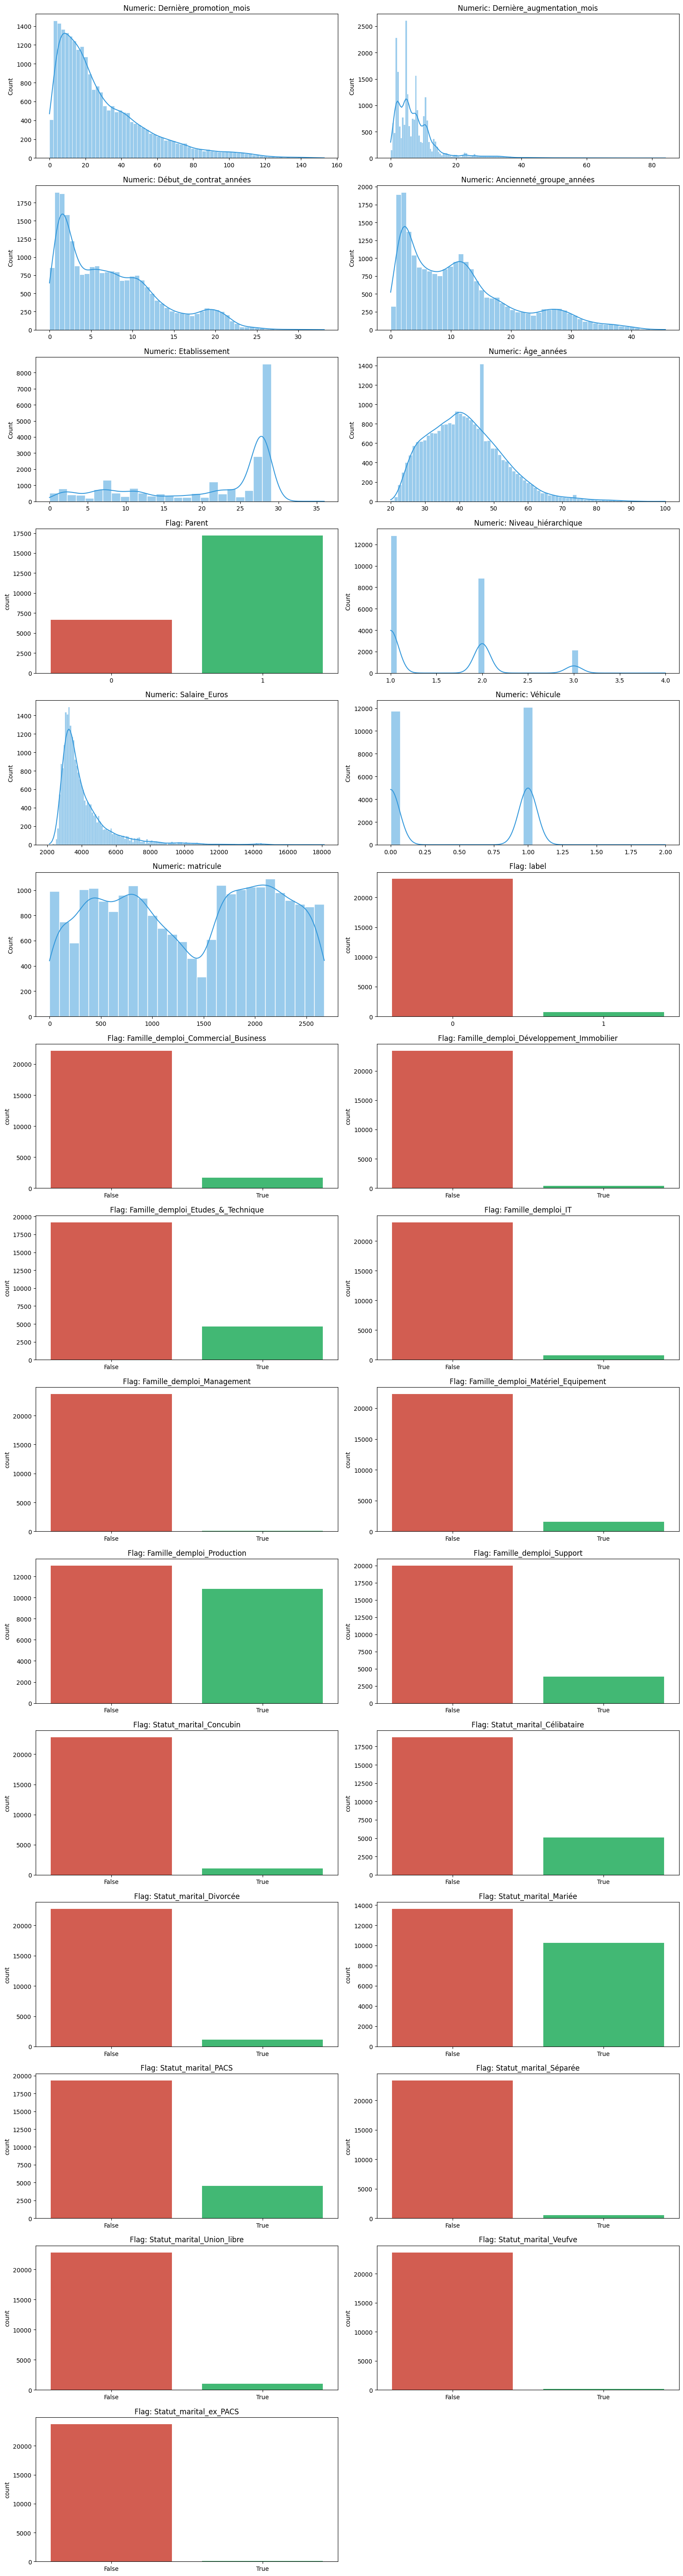

In [9]:
analysis_RH.plot_distributions(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'])

### Il y a-t-il des valeurs manquantes ?

In [10]:
CATEGORIES = {
    "Profil employé":          ["Âge (années)", "Statut marital", "Parent", "matricule"],
    "Contrat & Ancienneté":    ["Début de contrat (années)", "Ancienneté groupe (années)", "Etablissement", "Famille d'emploi"],
    "Rémunération":            ["Salaire (Euros)", "Véhicule", "Dernière augmentation (mois)", "Dernière promotion (mois)"],
    "Hiérarchie":              ["Niveau hiérarchique"],
    "Cible":                   ["label"],
}

for cat, cols in CATEGORIES.items():
    cols_ok = [c for c in cols if c in df.columns]
    print(f"\n── {cat} ──")
    for col in cols_ok:
        n = df[col].isnull().sum()
        pct = n / len(df) * 100
        print(f"  {col:<35} {n:>5} NaN  ({pct:.1f}%)")


── Profil employé ──
  Âge (années)                            0 NaN  (0.0%)
  Statut marital                          0 NaN  (0.0%)
  Parent                                  0 NaN  (0.0%)
  matricule                               0 NaN  (0.0%)

── Contrat & Ancienneté ──
  Début de contrat (années)               0 NaN  (0.0%)
  Ancienneté groupe (années)              0 NaN  (0.0%)
  Etablissement                           0 NaN  (0.0%)
  Famille d'emploi                        0 NaN  (0.0%)

── Rémunération ──
  Salaire (Euros)                         0 NaN  (0.0%)
  Véhicule                                0 NaN  (0.0%)
  Dernière augmentation (mois)            0 NaN  (0.0%)
  Dernière promotion (mois)               0 NaN  (0.0%)

── Hiérarchie ──
  Niveau hiérarchique                     0 NaN  (0.0%)

── Cible ──
  label                                   0 NaN  (0.0%)


Il n'y a pas de valeurs manquantes.

### Affichez la matrice de corrélation.

La matrice de corrélation est calculée sur l'ensemble des variables numériques et booléennes. Seules les variables présentant au moins une corrélation dont la valeur absolue dépasse **0.3** avec une autre variable sont conservées.

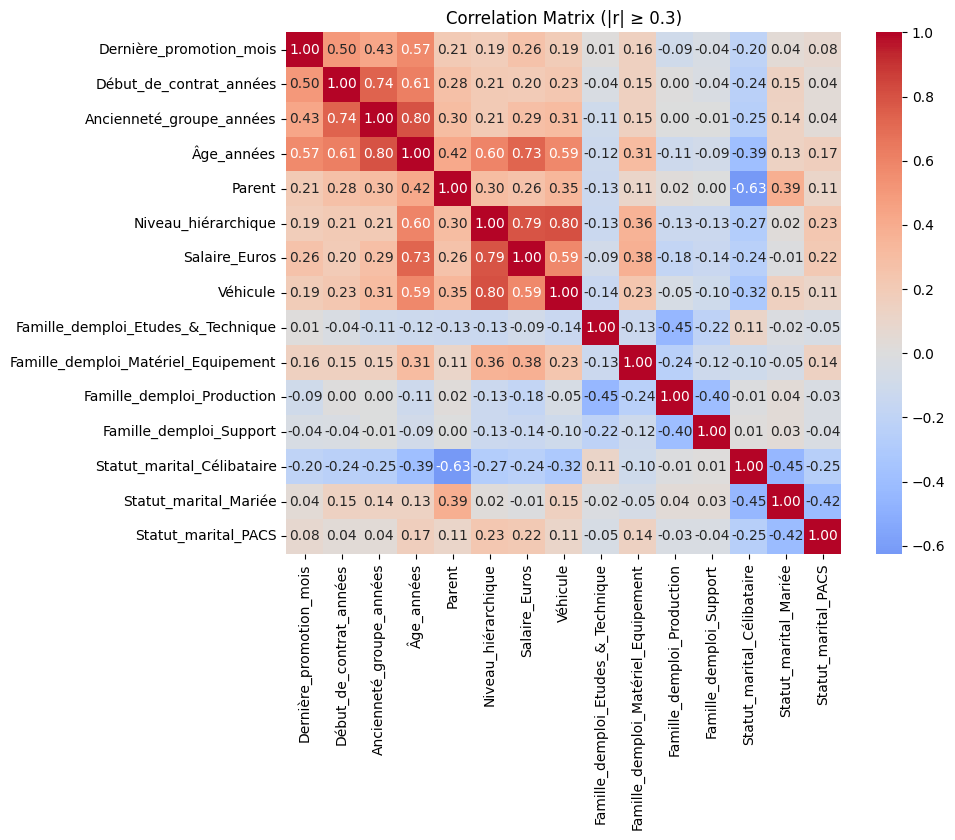

In [11]:
analysis_RH.plot_matrix_correlation(threshold=0.3)

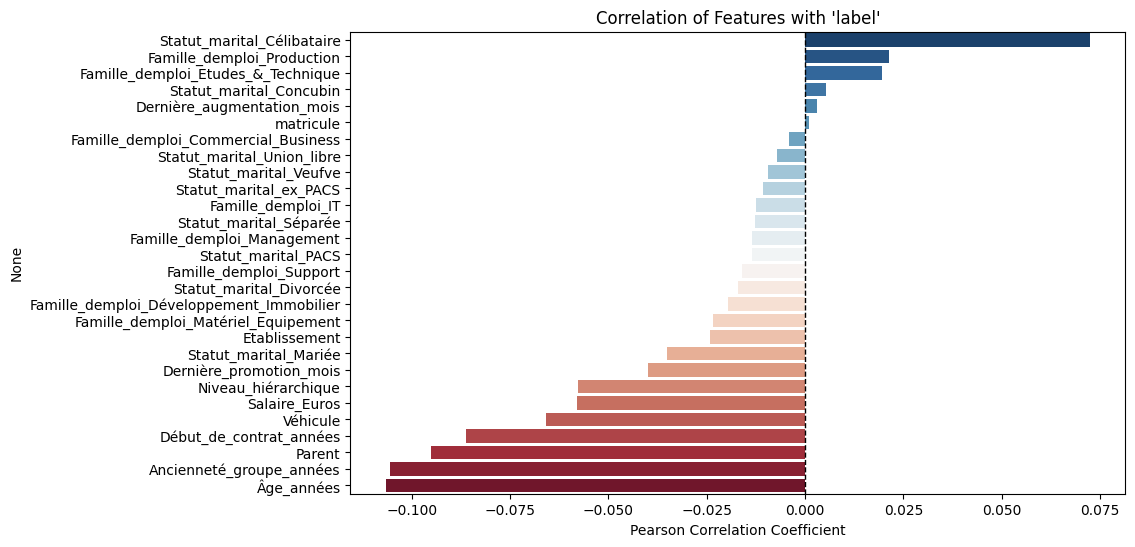

Statut_marital_Célibataire                  0.072513
Famille_demploi_Production                  0.021242
Famille_demploi_Etudes_&_Technique          0.019479
Statut_marital_Concubin                     0.005451
Dernière_augmentation_mois                  0.003011
matricule                                   0.001034
Famille_demploi_Commercial_Business        -0.003957
Statut_marital_Union_libre                 -0.007057
Statut_marital_Veufve                      -0.009308
Statut_marital_ex_PACS                     -0.010682
Famille_demploi_IT                         -0.012404
Statut_marital_Séparée                     -0.012591
Famille_demploi_Management                 -0.013484
Statut_marital_PACS                        -0.013513
Famille_demploi_Support                    -0.016009
Statut_marital_Divorcée                    -0.016953
Famille_demploi_Développement_Immobilier   -0.019704
Famille_demploi_Matériel_Equipement        -0.023319
Etablissement                              -0.

In [12]:
analysis_RH.target_correlation('label')

### Analyse de la corrélation

Variables des employés qui démissionnent:
- Les célibataires (value = 0.072)
- Les couples sans enfants (value = 0.005)
- La famille d'emploi production (value = 0.02)
- La famille d'emploi etude & technique (value = 0.02)

Variables d'attachement:
- Âge (value = -0.1)
- Ancienneté (value = -0.1)
- Avoir des enfants (value = -0.09)
- Le nombre d'années de début du contrat (value = -0.08)
- Avoir un véhicule de fonction (value = -0.06)
- Le salaire (value = -0.06)
- Le niveau hiérarchique (value = -0.06)

Nous pouvons observer que les variables des profils qui demissionnent le moins sont assez fortement corrélées entre elles.

On observe que toutes les variables corrélés sont <|0.1|, nous pouvons déduire qu'aucune des variables n'est uniquement responsable de la démission des employés. En effet, nous observons une multicorrélation entre les variables. Afin de determiner les schémas typiques, nous allons -ultérieurement- utiliser des modèles d'apprentissage. 

### Analyse d'un parcours d’un employé ayant démissionné VS employé n'ayant pas démissionné

In [13]:
n_demission = df[df['label'] == 0].iloc[0] # employé n'ayant pas démisionné au cours des 6 prochains mois
n_dem_matricule = n_demission['matricule']
n_dem_famille_emploi = n_demission['Famille d\'emploi']

demission = df[(df['label'] == 1) & (df['Famille d\'emploi'] == n_dem_famille_emploi)].iloc[0] # employé ayant démisionné au cours des 6 prochains mois avec la même famille d'emploi que l'employé n'ayant pas démisionné
dem_matricule = demission['matricule']

Aller chercher toutes les données de ces deux employés dans le dataframe traité pour reconstituer leur historique à partir de leurs matricules

In [14]:
n_dem_parcours = get_parcours(df, n_dem_matricule)
dem_parcours = get_parcours(df, dem_matricule)

Nombre de lignes pour le matricule 32 : 15
Nombre de lignes pour le matricule 2619 : 2


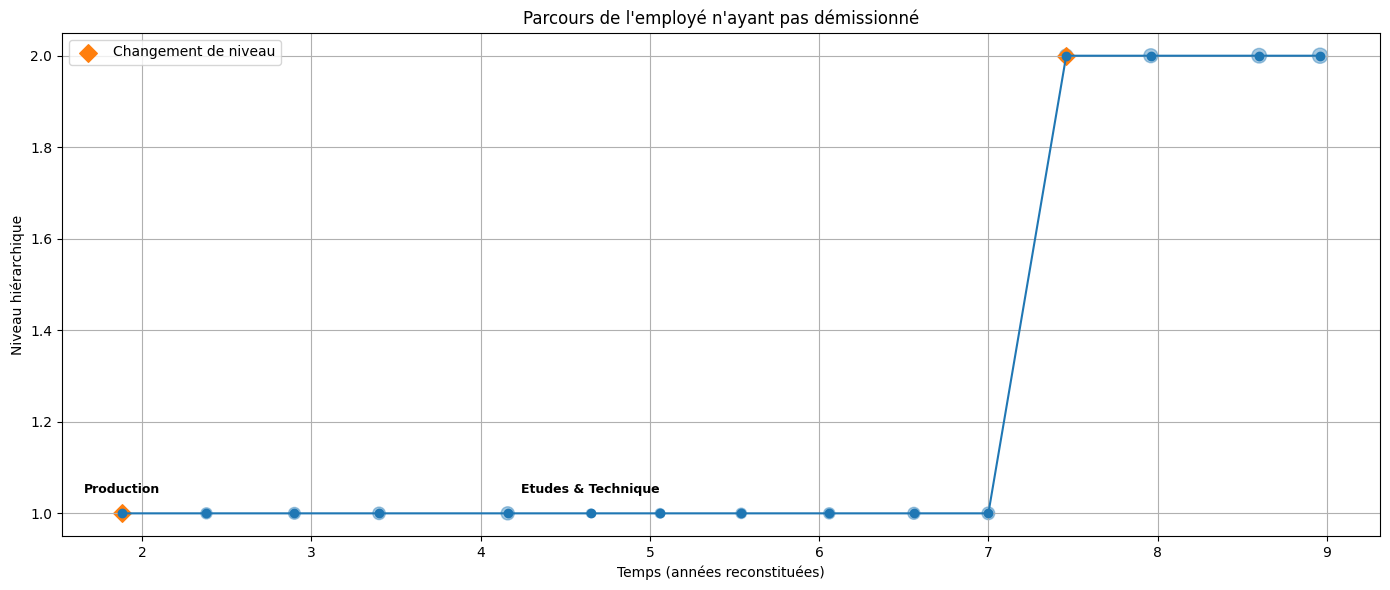

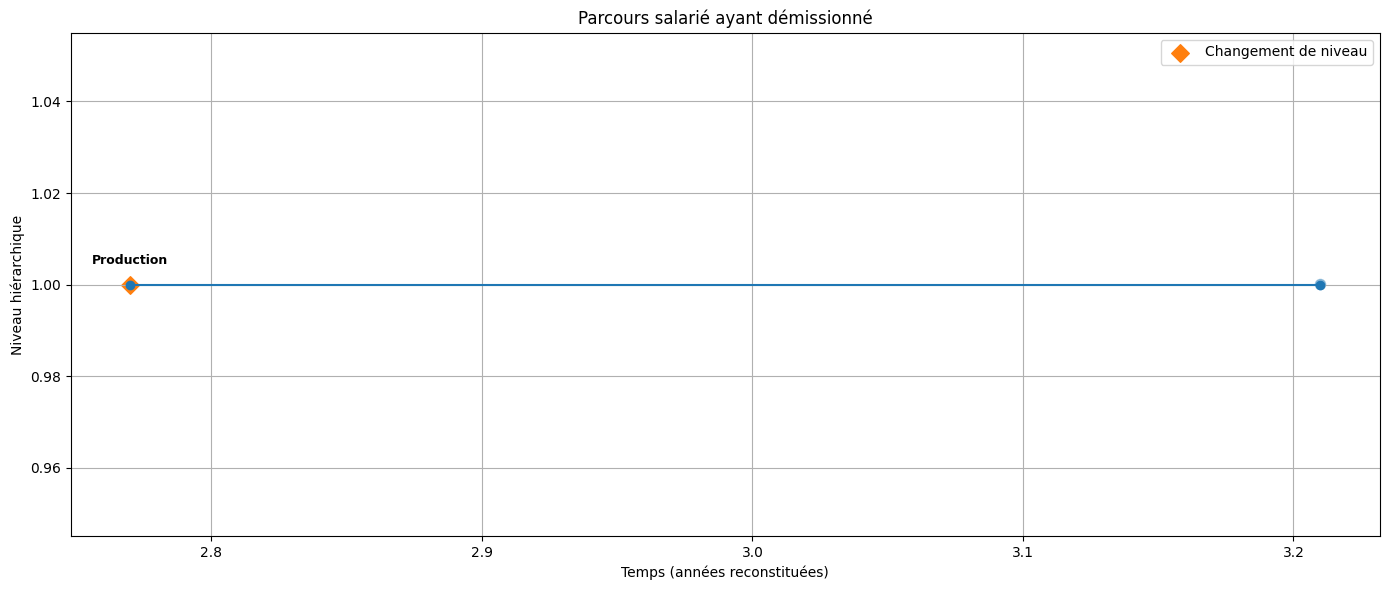

In [15]:
plot_parcours(n_dem_parcours, title="Parcours de l'employé n'ayant pas démissionné")
plot_parcours(dem_parcours, "Parcours salarié ayant démissionné")

## 2. Analyse des variables sensibles et biais potentiels

### Identifier les variables pouvant être considérées comme sensibles ou proxies, i.e. des variables qui permettent de deviner ou d’inférer des caractéristiques sensibles (e.g. la variable temps de pause maternité peut potentiellement révéler le sexe). (justifier votre réponse et classification)

Dans le cadre du RGPD et du Code du travail français, certaines variables sont considérées comme sensibles car elles exposent à un risque de discrimination ou d'atteinte à la vie privée.

### Variables directement sensibles

| Variable | Motif |
|---|---|
| `matricule` | Identifiant direct de l'individu |
| `Âge (années)` | Caractéristique protégée (discrimination) |
| `Statut marital` | Donnée relevant de la vie privée |
| `Parent` | Vecteur fréquent de discrimination à l'emploi |
| `Salaire (Euros)` | Donnée confidentielle ; discriminante si croisée |

### Variables à risque indirect (proxys potentiels)

| Variable | Biais potentiel |
|---|---|
| `Famille d'emploi` | Souvent corrélée au genre |
| `Niveau hiérarchique` | Proxy possible du genre ou de l'âge |
| `Ancienneté groupe` | Pénalise les interruptions de carrière (congés parentaux) |
| `Établissement` | Peut refléter une répartition corrélée à l'origine ou au niveau de vie |
| `Véhicule` | Indicateur indirect du niveau de vie |

Conclusion : le matricule doit être exclu de toute analyse : en tant qu'identifiant direct, il ne présente aucune valeur prédictive et expose inutilement à un risque de réidentification.

Pour les variables restantes, on suppose que les données ont préalablement fait l'objet d'un traitement d'anonymisation — perturbation des âges, généralisation des salaires, suppression ou codage des variables les plus exposées. Cette hypothèse permet de manipuler le jeu de données dans son état actuel, sans transformation supplémentaire. Elle n'exonère pas pour autant d'une vigilance sur les variables à risque indirect, dont le potentiel discriminatoire peut persister après anonymisation, notamment par croisement.

# Partie 2 - Données Images

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

c:\Users\celes\Desktop\3A_IA\[REXIA]\Project\REXAI_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.33G/1.33G [10:25<00:00, 2.28MB/s]

Extracting files...


Path to dataset files: C:\Users\celes\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2


## 1. Analyse du jeu de données

In [18]:
faces = Celeb_Faces(path)
faces.load_data()

### Analyse descriptive du jeu de données

In [19]:
analyzers = {} 

for key, df in faces.data.items():
    if df is not None:
        print(f"\n--- Analyse de : {key} ---")
        
        # On stocke l'objet Analyzer dans notre nouveau dictionnaire 'analyzers'
        analyzers[key] = Analyzer(df) 
        
        # Maintenant tu peux appeler tes méthodes
        inventory = analyzers[key].get_inventory()
        print(inventory)


--- Analyse de : attr_df ---
Dataset ready: 202599 rows and 41 columns.
                 Column   Type  Cardinality  Missing  \
0              image_id    str       202599        0   
1      5_o_Clock_Shadow  int64            2        0   
2       Arched_Eyebrows  int64            2        0   
3            Attractive  int64            2        0   
4       Bags_Under_Eyes  int64            2        0   
5                  Bald  int64            2        0   
6                 Bangs  int64            2        0   
7              Big_Lips  int64            2        0   
8              Big_Nose  int64            2        0   
9            Black_Hair  int64            2        0   
10           Blond_Hair  int64            2        0   
11               Blurry  int64            2        0   
12           Brown_Hair  int64            2        0   
13       Bushy_Eyebrows  int64            2        0   
14               Chubby  int64            2        0   
15          Double_Chin  int64 

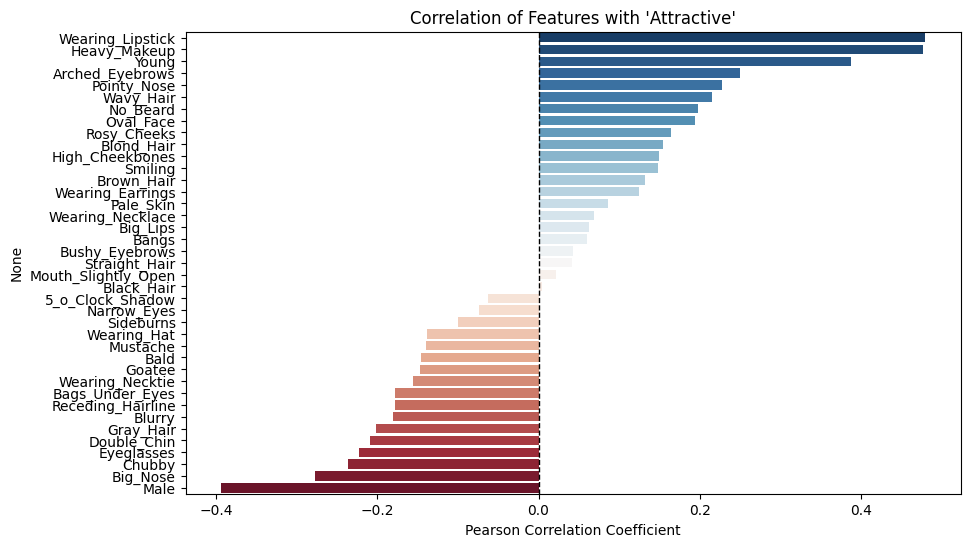

Wearing_Lipstick       0.480104
Heavy_Makeup           0.477084
Young                  0.387735
Arched_Eyebrows        0.250599
Pointy_Nose            0.228292
Wavy_Hair              0.214992
No_Beard               0.197655
Oval_Face              0.193939
Rosy_Cheeks            0.163867
Blond_Hair             0.154774
High_Cheekbones        0.149095
Smiling                0.147845
Brown_Hair             0.132069
Wearing_Earrings       0.124349
Pale_Skin              0.086051
Wearing_Necklace       0.068738
Big_Lips               0.062552
Bangs                  0.059712
Bushy_Eyebrows         0.042283
Straight_Hair          0.041550
Mouth_Slightly_Open    0.021465
Black_Hair             0.004140
5_o_Clock_Shadow      -0.062415
Narrow_Eyes           -0.073882
Sideburns             -0.100229
Wearing_Hat           -0.138636
Mustache              -0.140182
Bald                  -0.145826
Goatee                -0.146613
Wearing_Necktie       -0.156420
Bags_Under_Eyes       -0.178464
Receding

In [20]:
analyzers["attr_df"].target_correlation("Attractive")

Analyse des corrélations


--- Analyse de : attr_df ---


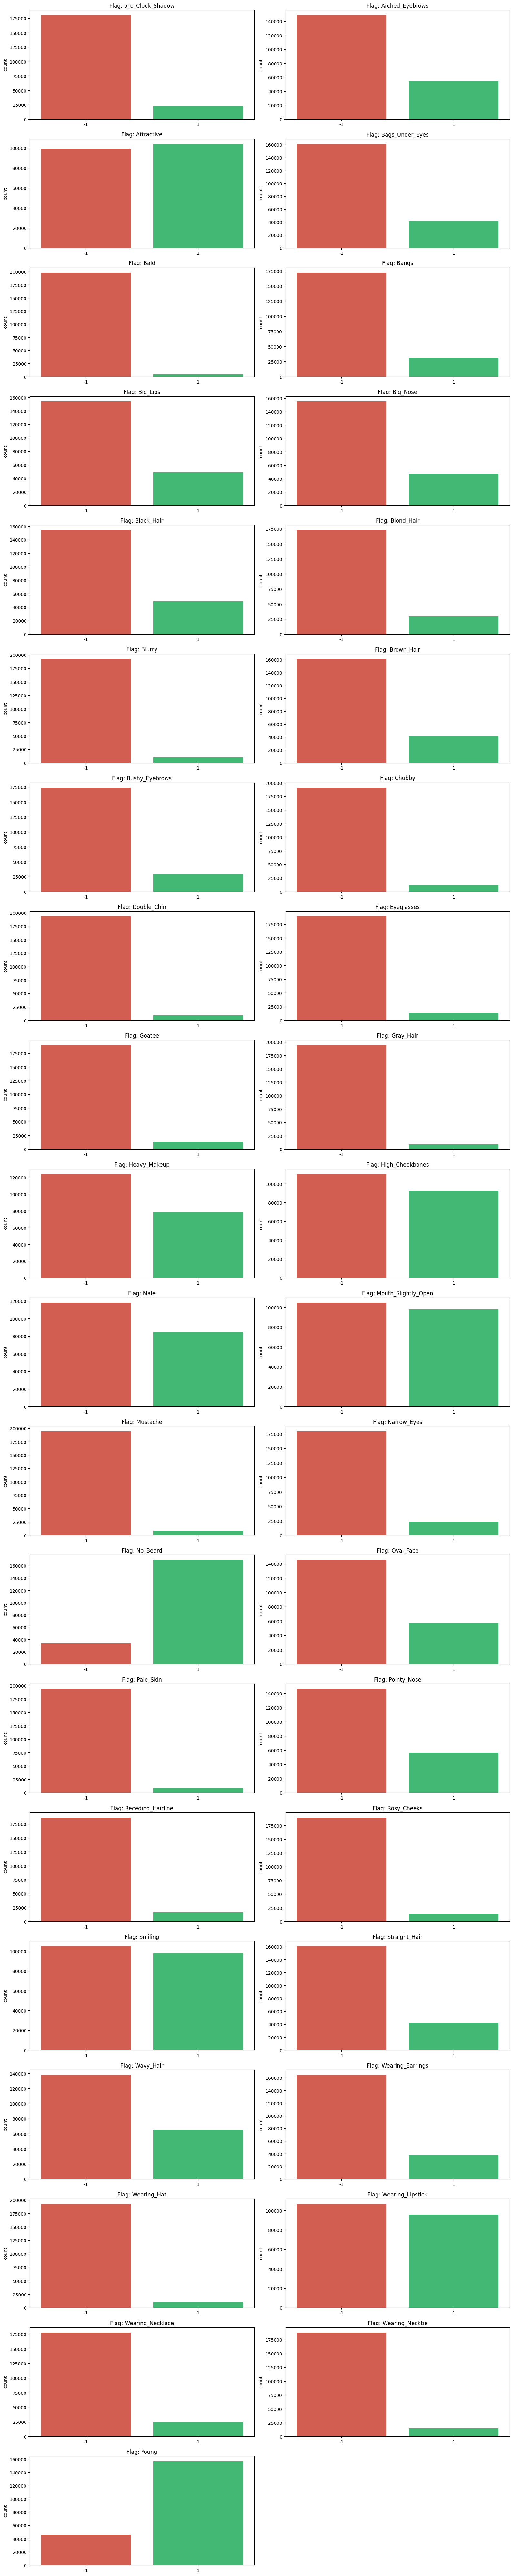


--- Analyse de : partition_df ---


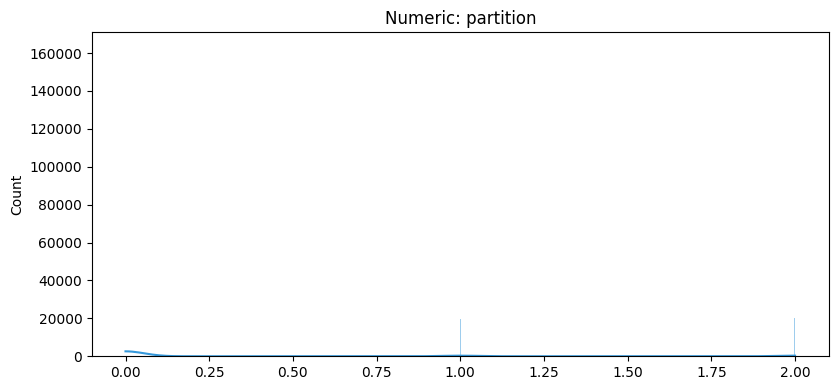


--- Analyse de : bbox_df ---


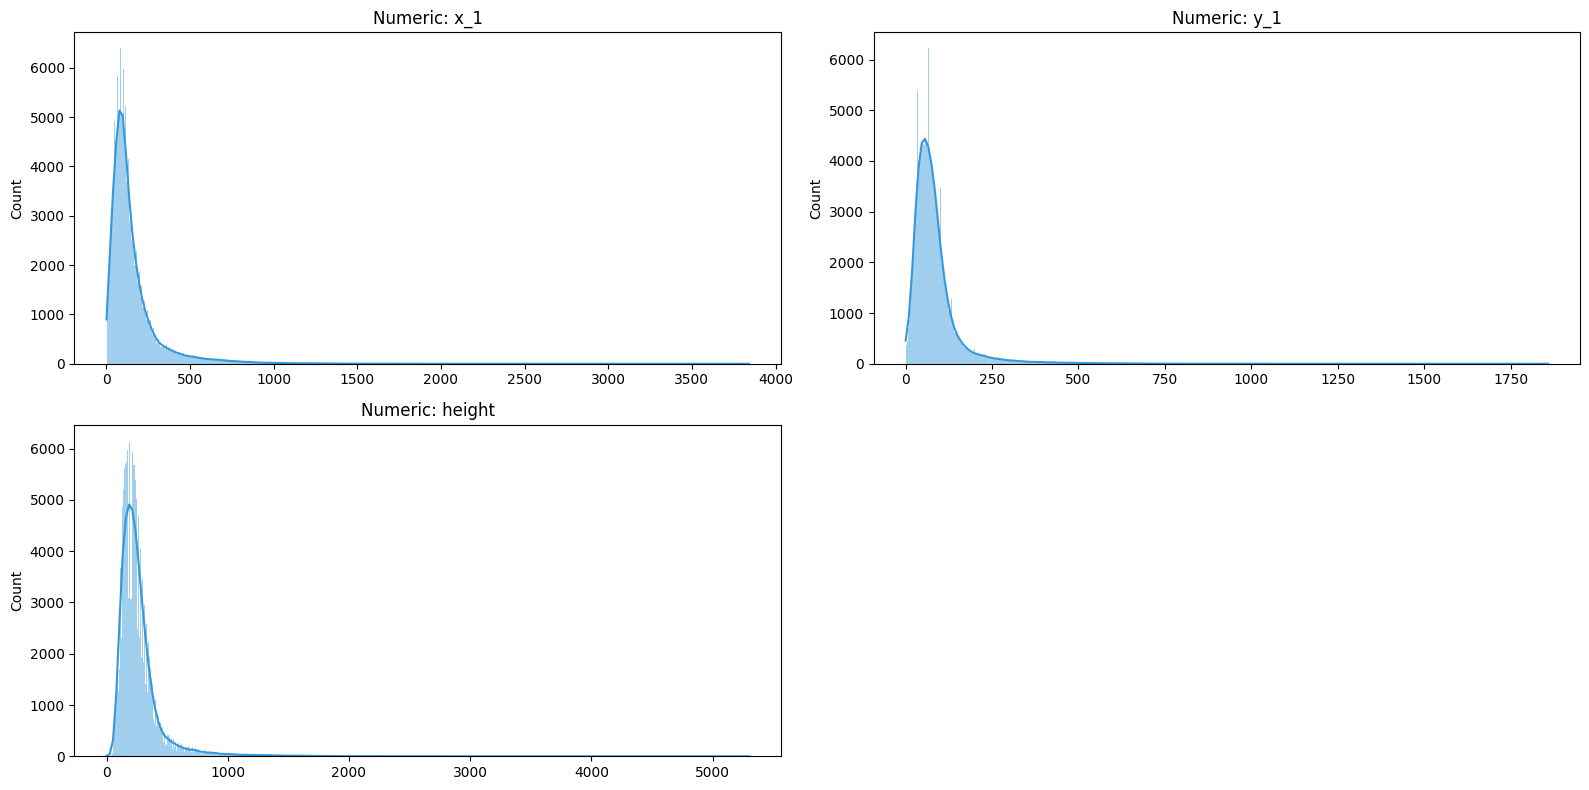


--- Analyse de : landmarks_df ---


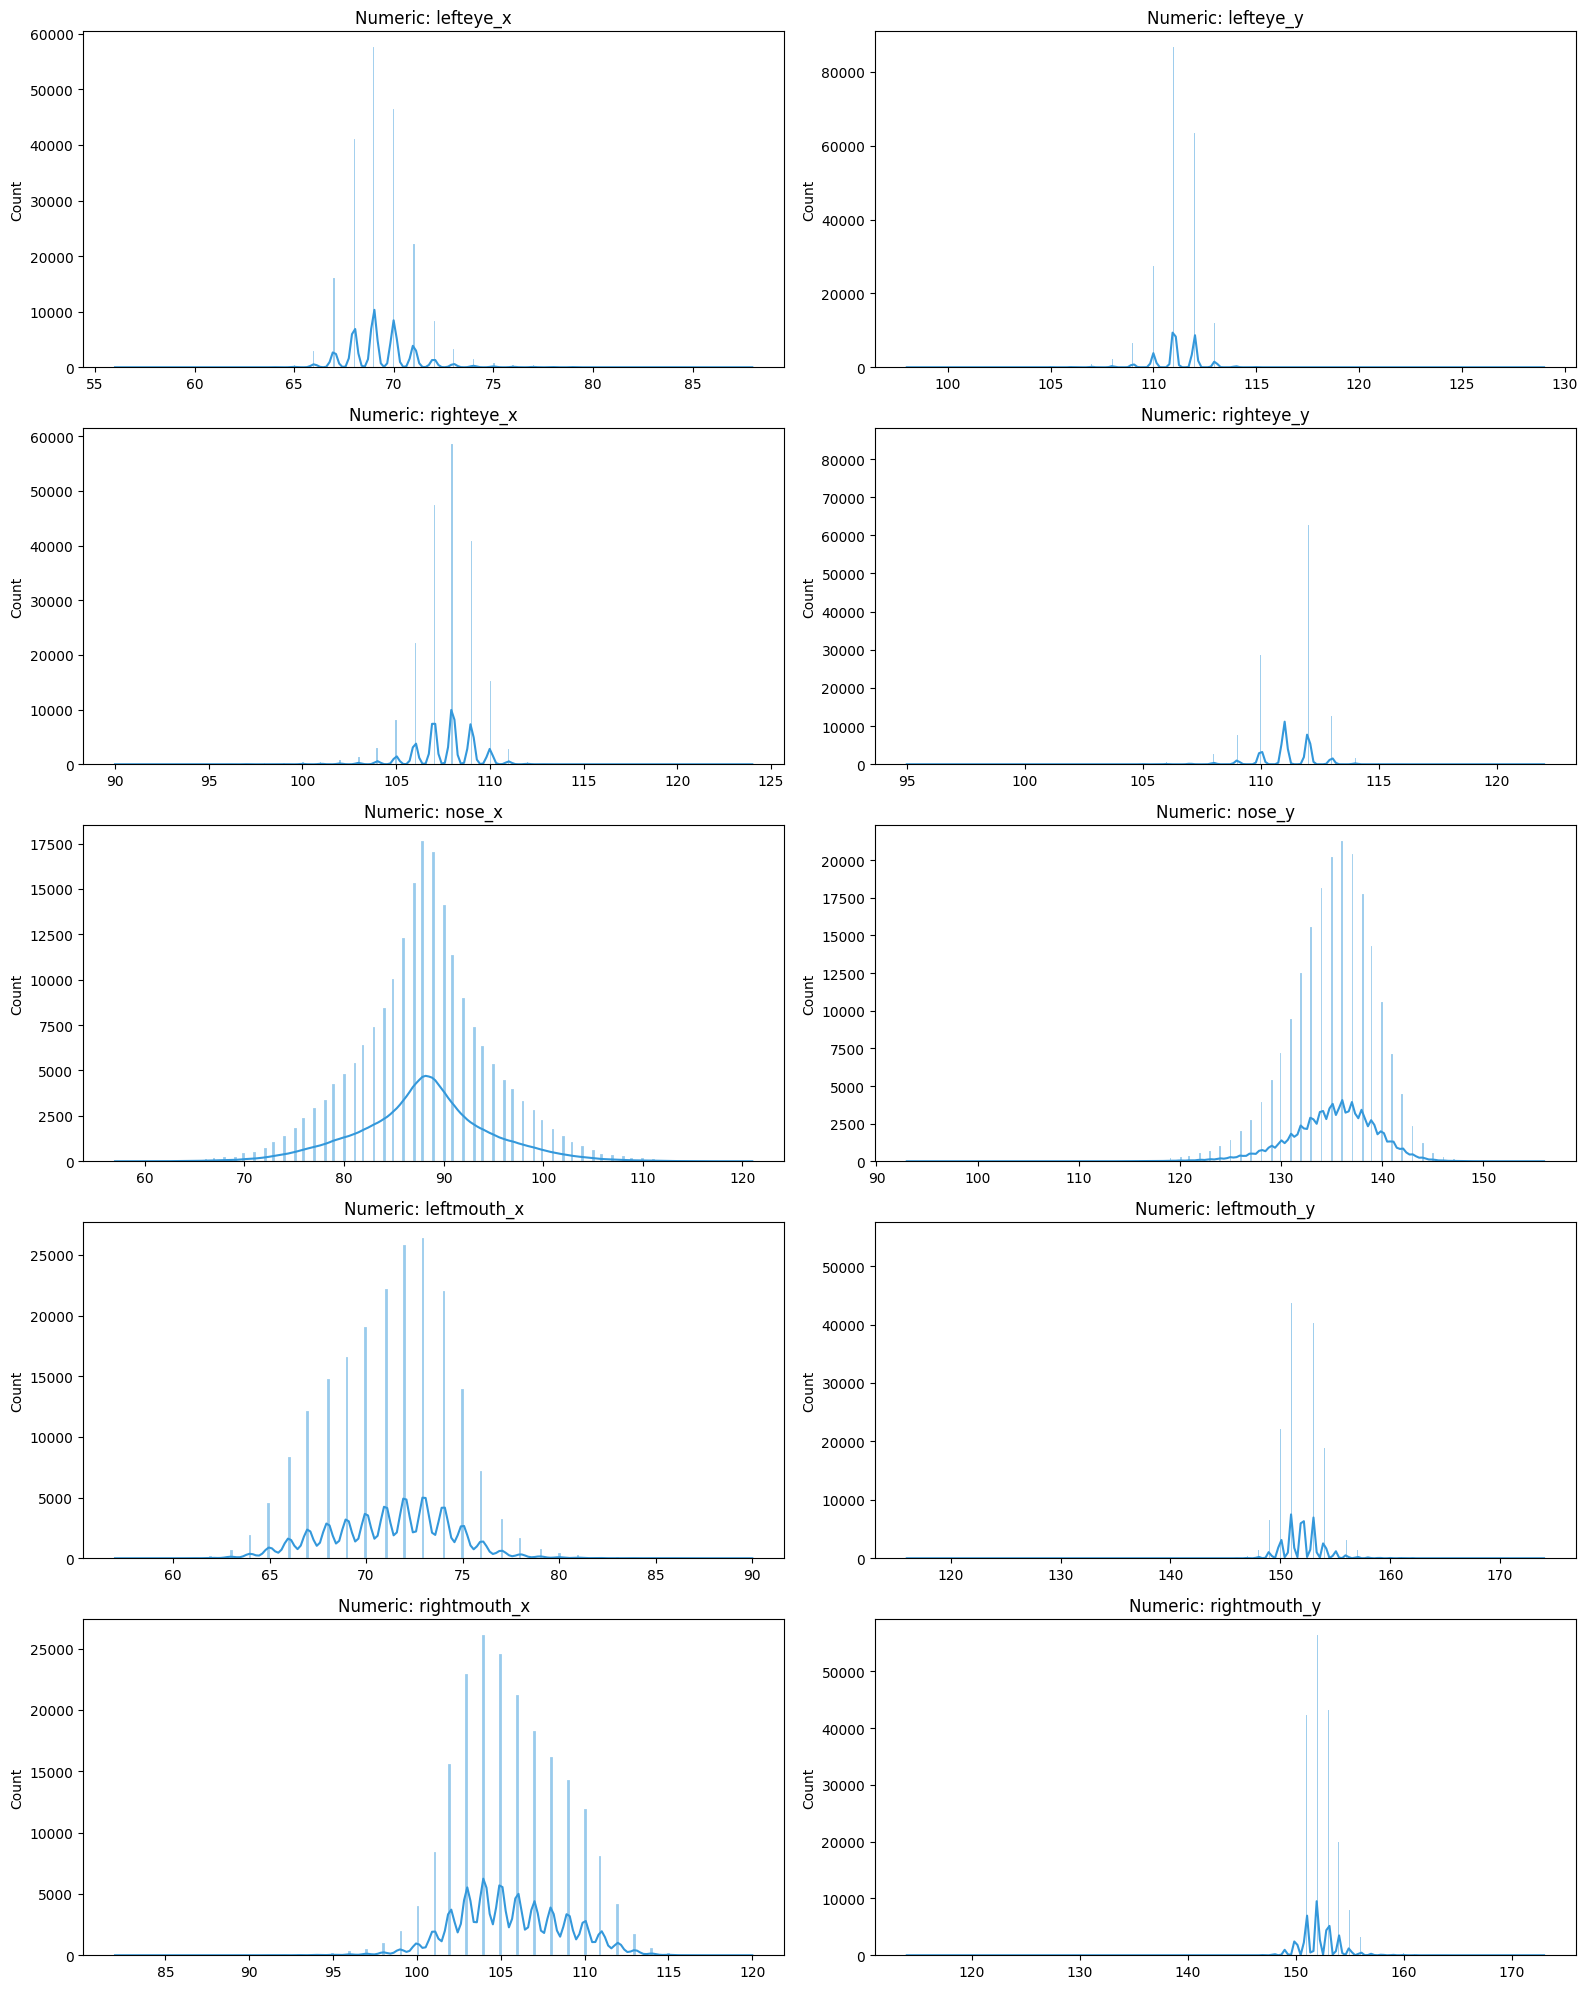

In [21]:
for key, df in faces.data.items():
    if df is not None:
        print(f"\n--- Analyse de : {key} ---")
        analyzers[key].plot_distributions()

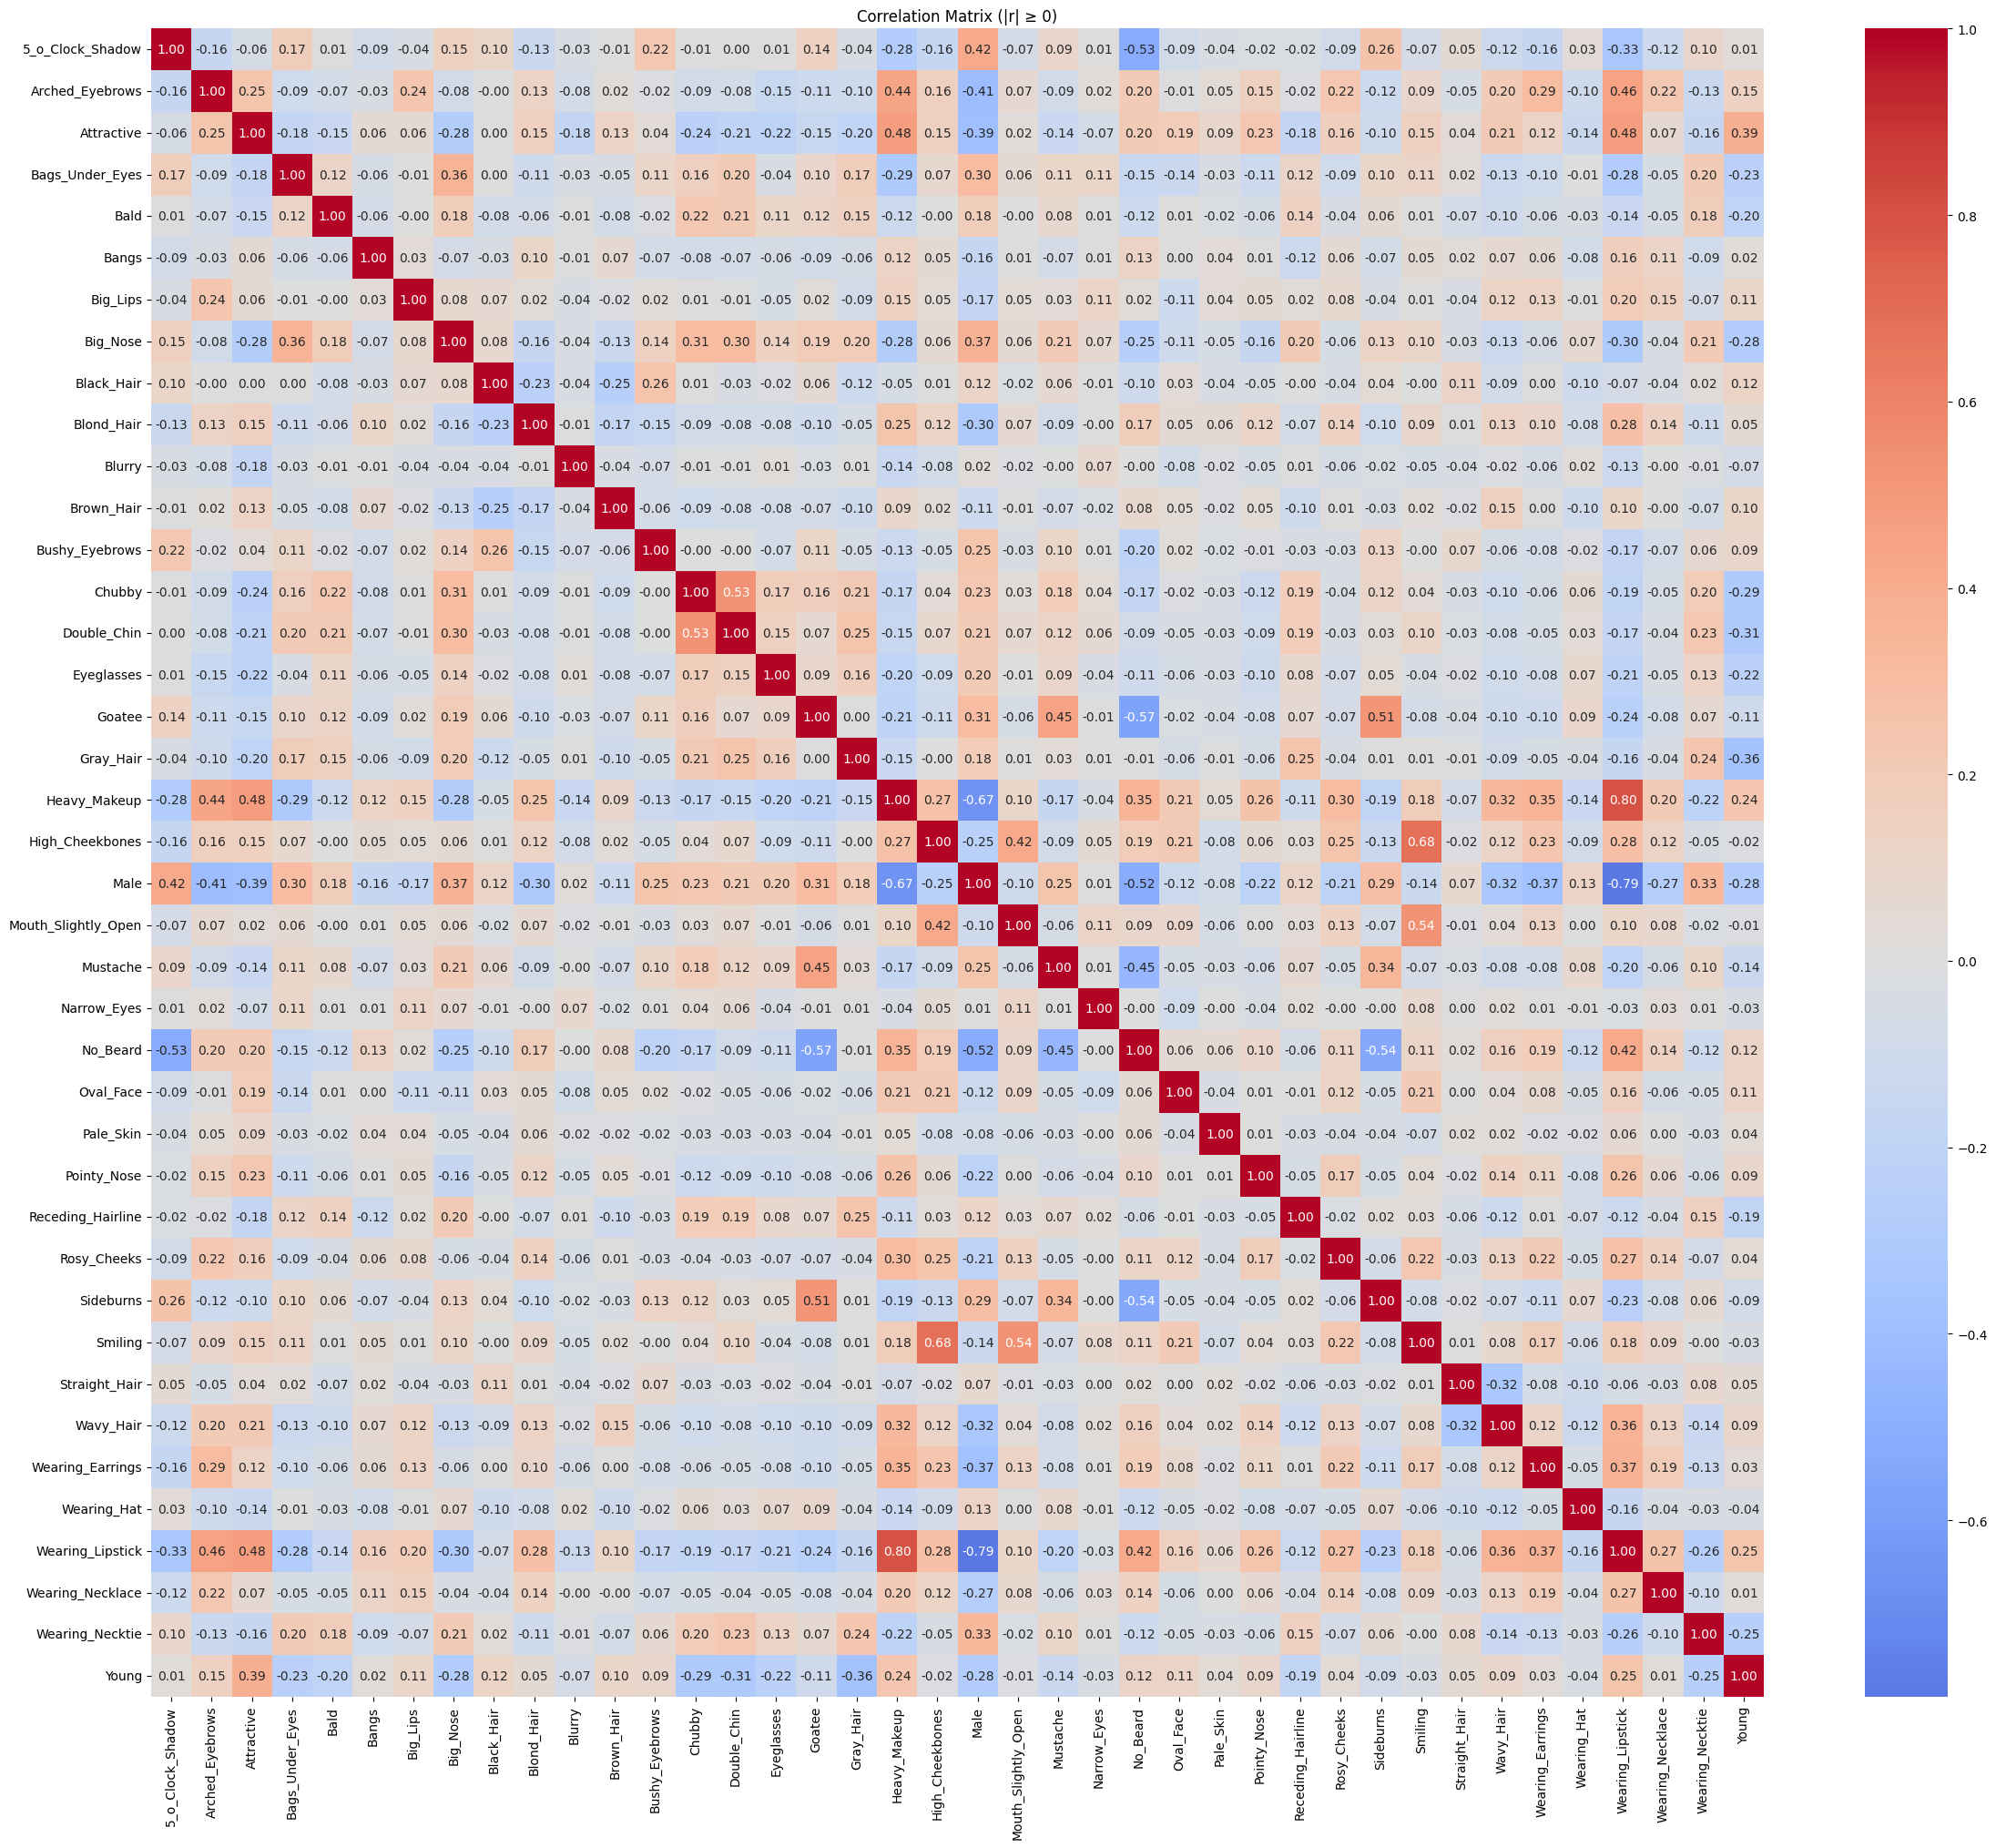

In [22]:
analyzers["attr_df"].plot_matrix_correlation(threshold=0)

*Exhiber au moins une corrélation artificielle*

### Identification de variables sensibles (ex. Genre (male/female), Couleur de peau, Âge, Contexte culturel. Justifier votre classification (pour sont-elles sensibles ? …)

### Analyse de disparité: Certains groupes sont-ils sous-représentés ? Le dataset reflète-t-il un biais de collecte ? Révèle-t-il d’autres biais ?

### Analyse de la fairness: nous allons nous intéresser aux deux métriques de fairness ci-dessous. Elles se basent sur un attribut sensible (S) et comparent avec un attribut à étudier (Y). Nous allons considérer deux attributs sensibles: Male et Pale_Skin. Calculer la valeur de ces métriques pour tous les autres attributs. 

## 2. Apprentissage automatique

### Entraîner un modèle en utilisant les images en entrée et l’attribut Smiling.. Justifier le choix de votre modèle. Décrivez et commentez les résultats.

### Évaluation de l’équité: Comparer les performances par sous-groupes sensibles : (e.g. Accuracy par genre, FPR / FNR par groupe, Écart de performance entre groupes)

## 3. Explication post-hoc

### Appliquez deux méthodes d’explication post-hoc

### Générer des explications locales pour un cas correct, un cas incorrect et un cas de groupe minoritaire

### commenter et conclure sur votre modèle.

### Si le modèle n’a pas appris le bon concept, proposer une intervention et recommencer.